In [20]:
# Magics
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import matplotlib.pyplot as plt
plt.style.use('default')  # Resets to standard white background
import seaborn as sns
sns.set_theme()
sns.set_style('ticks')
sns.set_context('talk')
from ephys.decoder import *

# Load data

## Load spike counts

In [22]:
subject = '007'
folder_parent = Path.home() / 'data' / subject

ephys_ids = [
    '007_2024-06-22_10-48-57',
    '007_2024-06-23_12-46-55',
    '007_2024-06-24_17-47-22',
    '007_2024-06-25_15-54-23',
    '007_2024-06-26_15-19-30',
    '007_2024-06-27_15-06-28',
    '007_2024-06-28_14-18-51',
    '007_2024-06-29_16-24-52',
    # '007_2024-07-06_11-16-25',  # Bad session
    # '007_2024-07-07_13-20-29',  # Bad session
    '007_2024-07-08_12-20-29',
    '007_2024-07-09_12-10-57',
    '007_2024-07-10_12-03-35',
    '007_2024-07-11_12-39-21',
    '007_2024-07-12_13-29-26'
]

# Load spike counts for all neurons of a session (bins, all_psth). If file doesn't exist, create it
for i in range(len(ephys_ids)):

    print(f'Processing session {i + 1}/{len(ephys_ids)}: {ephys_ids[i]}...')

    # Create child folder within parent folder for each ephys_id with its name if it doesn't exist
    folder_child = folder_parent / ephys_ids[i]
    folder_child.mkdir(parents=True, exist_ok=True)
    os.chdir(folder_child)

    # Get spike counts
    if any(f.endswith('.npy') for f in os.listdir(folder_child)):
        print('Files exist in folder. Skipping')
        continue
    else:
        print('Files do not exist in folder. Proceeding')
        df_ttl, df_behavior, n_trials, df_spikes, cluster_info, x, height, labels, y, width, left, ts_edges, events_edges = \
            preprocess(ephys_ids[i])
        bins, all_psth = get_all_psth(cluster_info, df_spikes, df_ttl, n_trials, time_win=[-1, 3], bin_size=0.1)
    # Save bins and psth
    np.save(folder_child / 'bins.npy', bins)
    np.save(folder_child / 'all_psth.npy', all_psth)

Processing session 1/13: 007_2024-06-22_10-48-57...
Files exist in folder. Skipping
Processing session 2/13: 007_2024-06-23_12-46-55...
Files exist in folder. Skipping
Processing session 3/13: 007_2024-06-24_17-47-22...
Files exist in folder. Skipping
Processing session 4/13: 007_2024-06-25_15-54-23...
Files exist in folder. Skipping
Processing session 5/13: 007_2024-06-26_15-19-30...
Files exist in folder. Skipping
Processing session 6/13: 007_2024-06-27_15-06-28...
Files exist in folder. Skipping
Processing session 7/13: 007_2024-06-28_14-18-51...
Files exist in folder. Skipping
Processing session 8/13: 007_2024-06-29_16-24-52...
Files exist in folder. Skipping
Processing session 9/13: 007_2024-07-08_12-20-29...
Files exist in folder. Skipping
Processing session 10/13: 007_2024-07-09_12-10-57...
Files exist in folder. Skipping
Processing session 11/13: 007_2024-07-10_12-03-35...
Files exist in folder. Skipping
Processing session 12/13: 007_2024-07-11_12-39-21...
Files exist in folder

## Load behavior

In [23]:
# Load behavior of a session (bins, all_psth). If file doesn't exist, create it
for i in range(len(ephys_ids)):

    path_behavior = get_behavior_id(ephys_ids[i])
    filename = path_behavior.name
    print(f'Parsing behavioral session {i + 1}/{len(ephys_ids)}: {filename[:-4]}...')

    # Create child folder within parent folder for each ephys_id with its name if it doesn't exist
    folder_child = folder_parent / ephys_ids[i]
    folder_child.mkdir(parents=True, exist_ok=True)
    os.chdir(folder_child)

    # Execute only if folder is empty
    if any(f.endswith('.csv') for f in os.listdir(folder_child)):
        print('File exist in folder. Skipping')
        continue
    else:
        print('File does not exist in folder. Proceeding')
        df_behavior = parse_v2(path_behavior)
        df_behavior.to_csv(folder_child / filename, index=False)


behavior = []
for i in range(len(ephys_ids)):
    path_behavior = get_behavior_id(ephys_ids[i])
    filename = path_behavior.name
    folder_child = folder_parent / ephys_ids[i]
    df = pd.read_csv(folder_child / filename)
    behavior.append(df)

# # Get behavioral events
# stim_dur = df_behavior.StimDur.unique()[0]
# delay = df_behavior.Delay.unique()[0]
# go_cue = stim_dur + delay

Parsing behavioral session 1/13: 007_stage_training_v5_20240622-110354...
File exist in folder. Skipping
Parsing behavioral session 2/13: 007_stage_training_v5_20240623-130152...
File exist in folder. Skipping
Parsing behavioral session 3/13: 007_stage_training_v5_20240624-180217...
File exist in folder. Skipping
Parsing behavioral session 4/13: 007_stage_training_v5_20240625-160924...
File exist in folder. Skipping
Parsing behavioral session 5/13: 007_stage_training_v5_20240626-153431...
File exist in folder. Skipping
Parsing behavioral session 6/13: 007_stage_training_v5_20240627-152129...
File exist in folder. Skipping
Parsing behavioral session 7/13: 007_stage_training_v5_20240628-143350...
File exist in folder. Skipping
Parsing behavioral session 8/13: 007_stage_training_v5_20240629-163958...
File exist in folder. Skipping
Parsing behavioral session 9/13: 007_stage_training_v5_20240708-123523...
File exist in folder. Skipping
Parsing behavioral session 10/13: 007_stage_training_v5

In [24]:
disengaged = [get_disengaged(behavior[_], plot=False) for _ in range(len(behavior))]

# Within Temporal Decoder (mean)

In [25]:
%%time
# Run mean within decoder across sessions
# results = mean_decoder(kind='within', save=True, plot=False)

CPU times: total: 0 ns
Wall time: 0 ns


In [26]:
# Load mean within decoder results across sessions
with open(Path(folder_parent / 'results_mean_within_decoder.pkl'), 'rb') as f:
    results = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n007, 13 sessions, 9513 trials')

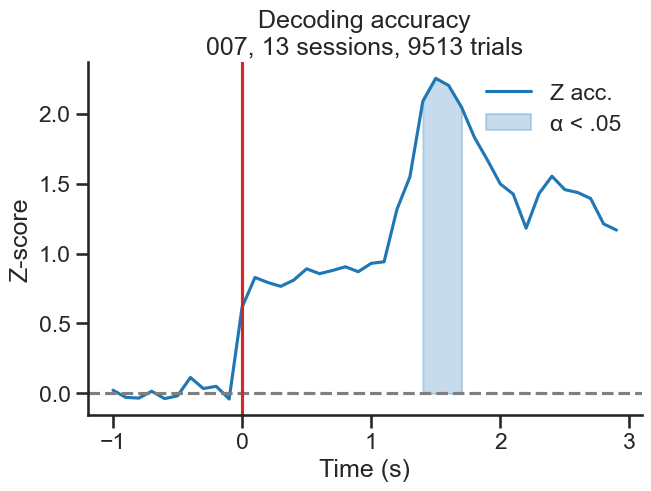

In [27]:
# Plot mean within decoder results across sessions
plot_mean_within_decoder(results, z_null=True)
n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
plt.title(f"Decoding accuracy\n"
          f"{subject}, {len(results['acc'])} sessions, {n_trials} trials")

# Cross Temporal Decoder (mean)

In [28]:
%%time
# Run mean cross decoder across sessions
# results = mean_decoder(kind='cross', save=True, plot=False)

CPU times: total: 0 ns
Wall time: 0 ns


In [29]:
# Load mean cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_cross_decoder.pkl'), 'rb') as f:
    results = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n 007, 13 sessions, 9513 trials')

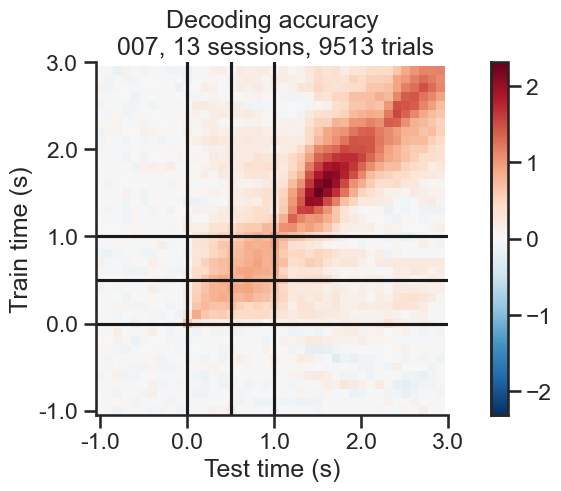

In [30]:
# Plot mean within decoder results across sessions
plot_mean_cross_decoder(results, z_null=True)
n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
plt.title(f"Decoding accuracy\n"
          f" {subject}, {len(results['acc'])} sessions, {n_trials} trials")

# Epoch Cross Temporal Decoder (mean)

In [31]:
%%time
# Run mean epoch cross decoder across sessions
# results_stim = mean_decoder(kind='epoch', epoch='stim', save=True, plot=False)
# results_delay = mean_decoder(kind='epoch', epoch='delay', save=True, plot=False)
# results_resp = mean_decoder(kind='epoch', epoch='resp', save=True, plot=False)

CPU times: total: 0 ns
Wall time: 0 ns


In [43]:
# Load mean epoch cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim.pkl'), 'rb') as f:
    results_stim = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay.pkl'), 'rb') as f:
    results_delay = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp.pkl'), 'rb') as f:
    results_resp = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n007, 13 sessions, 9513 trials')

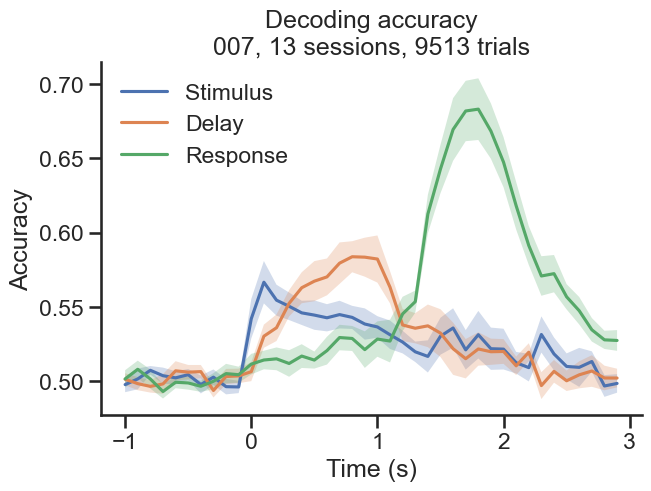

In [33]:
# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim, epoch='stim', z_null=False)
plot_mean_epoch_cross_decoder(results_delay, epoch='delay', z_null=False)
plot_mean_epoch_cross_decoder(results_resp, epoch='resp', z_null=False)
n_trials = np.sum([results_stim['pred'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {len(results_stim["acc"])} sessions, {n_trials} trials')

# Epoch Cross Temporal Decoder Split (mean)

## Stimulus Code Split by Outcome (blue trace in previous plot)
2 approaches that should lead to the same mean accuracy but **different** null accuracy:
1. Run the epoch cross decoder function above for all trials and then average across trial types according to split (e.g. splitting by outcome in correct/error trials). Mean null  accuracy should be the **same** for each split (flat at 0.5). This is **wrong**
2. Run the epoch cross decoder split function that performs the split when training the decoder. Mean null accuracy should be **different** for each split. This is **correct**

### 1. Run epoch cross decoder function for all trials and average across trial types

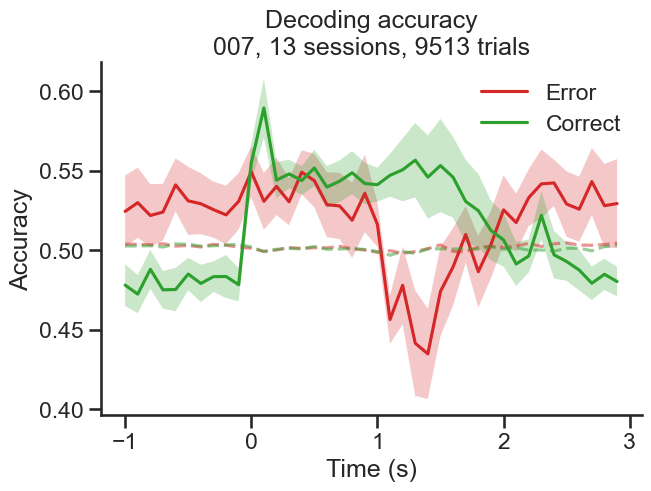

In [44]:
# Split stim decoder into correct vs error trials
# behavior = [behavior[i][behavior[i].Miss==0].reset_index(drop=True) for i in range(len(behavior))]
indexes = [get_trial_indexes(behavior[i], condition='outcome') for i in range(len(behavior))]
# indexes = [get_trial_indexes(behavior[i][behavior[i].Miss==0].reset_index(drop=True), condition='outcome') for i in range(len(behavior))]

# hits = [list(np.where(behavior[i].Hit == True)[0]) for i in range(len(behavior))]
# errors = [list(np.where(behavior[i].Hit == False)[0]) for i in range(len(behavior))]
# misses = [np.where(np.isnan(behavior[i].Hit))[0] for i in range(len(behavior))]
# indexes = [[h, e] for h, e in zip(hits, errors)]

# Error trials
acc_mean_error = [np.mean(results_stim['acc'][i][indexes[i][0]], axis=0) for i in range(len(results_stim['acc']))]
acc_mean_error = np.array(acc_mean_error)
acc_sem_error = sem(acc_mean_error, axis=0)
acc_mean_error = np.mean(acc_mean_error, axis=0)
acc_null_mean_error = [np.mean(results_stim['acc_null'][i][indexes[i][0]], axis=(0, 2)) for i in range(len(results_stim['acc_null']))]
acc_null_mean_error = np.array(acc_null_mean_error)
acc_null_mean_error = np.mean(acc_null_mean_error, axis=0)

# Correct trials
acc_mean_correct = [np.mean(results_stim['acc'][i][indexes[i][1]], axis=0) for i in range(len(results_stim['acc']))]
acc_mean_correct = np.array(acc_mean_correct)
acc_sem_correct = sem(acc_mean_correct, axis=0)
acc_mean_correct = np.mean(acc_mean_correct, axis=0)
acc_null_mean_correct = [np.mean(results_stim['acc_null'][i][indexes[i][1]], axis=(0, 2)) for i in range(len(results_stim['acc_null']))]
acc_null_mean_correct = np.array(acc_null_mean_correct)
acc_null_mean_correct = np.mean(acc_null_mean_correct, axis=0)

plt.figure(constrained_layout=True)

# Error trials
plt.plot(results_stim['bins'][:-1], acc_mean_error, color='tab:red', label='Error')
plt.fill_between(results_stim['bins'][:-1], acc_mean_error - acc_sem_error,
                 acc_mean_error + acc_sem_error, color='tab:red', edgecolor='none',
                 alpha=0.25)
plt.plot(results_stim['bins'][:-1], acc_null_mean_error, color='tab:red', ls='--', alpha=0.5)

# Correct trials
plt.plot(results_stim['bins'][:-1], acc_mean_correct, color='tab:green', label='Correct')
plt.fill_between(results_stim['bins'][:-1], acc_mean_correct - acc_sem_correct,
                 acc_mean_correct + acc_sem_correct, color='tab:green', edgecolor='none',
                 alpha=0.25)
plt.plot(results_stim['bins'][:-1], acc_null_mean_correct, color='tab:green', ls='--', alpha=0.5)

n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {len(results_stim["acc"])} sessions, {n_trials} trials')
plt.xlabel('Time (s)')
plt.ylabel('Accuracy')
plt.legend(frameon=False)
sns.despine()

Note the same mean null accuracy for both splits. This is wrong.

### 2. Run epoch cross decoder split function that performs the split when training the decoder

In [35]:
%%time
# Run mean epoch cross decoder split across sessions
# results = mean_epoch_cross_decoder_split(epoch='stim', split_by='Hit', save=True, plot=False)

CPU times: total: 0 ns
Wall time: 0 ns


In [36]:
# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_split_by_Hit.pkl'), 'rb') as f:
    results = pickle.load(f)

In [37]:
# Load epoch cross decoder split results across sessions
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_split_by_Hit.pkl'), 'rb') as f:
#     results = pickle.load(f)

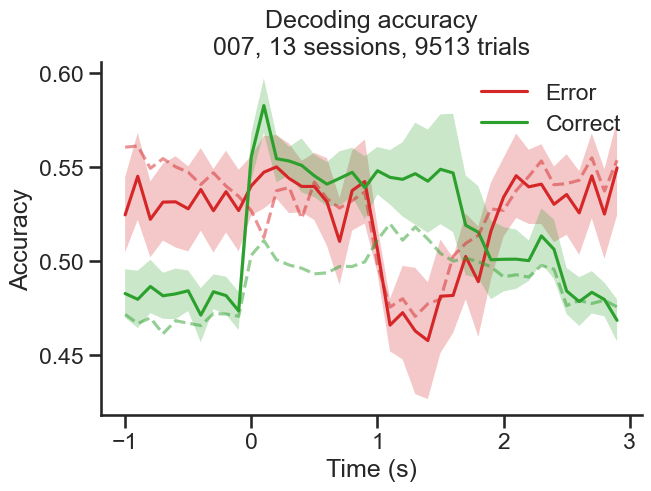

In [39]:
# Plot mean accuracy epoch stimulus decoder split by Hit
acc0_mean = np.nanmean([np.nanmean(results['acc0'][i], axis=0) for i in range(len(results["acc0"]))], axis=0)
acc0_sem = sem([np.nanmean(results['acc0'][i], axis=0) for i in range(len(results["acc0"]))], axis=0)
acc_null0_mean = np.nanmean([(np.nanmean(results['acc_null0'][i], axis=(0, 2))) for i in range(len(results['acc_null0']))], axis=0)
acc1_mean = np.nanmean([np.nanmean(results['acc1'][i], axis=0) for i in range(len(results["acc1"]))], axis=0)
acc1_sem = sem([np.nanmean(results['acc1'][i], axis=0) for i in range(len(results["acc1"]))], axis=0)
acc_null1_mean = np.nanmean([(np.nanmean(results['acc_null1'][i], axis=(0, 2))) for i in range(len(results['acc_null1']))], axis=0)

plt.figure(constrained_layout=True)
plt.plot(results['bins'][:-1], acc0_mean, color='tab:red', label='Error')
plt.fill_between(results['bins'][:-1], acc0_mean - acc0_sem, acc0_mean + acc0_sem, color='tab:red', edgecolor='none', alpha=0.25)
plt.plot(results['bins'][:-1], acc1_mean, color='tab:green', label='Correct')
plt.fill_between(results['bins'][:-1], acc1_mean - acc1_sem, acc1_mean + acc1_sem, color='tab:green', edgecolor='none', alpha=0.25)
plt.plot(results['bins'][:-1], acc_null0_mean, color='tab:red', alpha=0.5, linestyle='--')
plt.plot(results['bins'][:-1], acc_null1_mean, color='tab:green', alpha=0.5, linestyle='--')

n_trials = np.sum([results['acc0'][i].shape[0] for i in range(len(results['acc0']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {len(results_stim["acc"])} sessions, {n_trials} trials')
plt.xlabel('Time (s)')
plt.ylabel('Accuracy')
plt.legend(frameon=False)
sns.despine()

# Plot comment
For error trials (red) the shuffles follow the downward trend of the code because in every erro trial the animal licked to the opposite side of stimulus (what I am decoding).
What is more weird is that there's also a lot of code in correct trials's shuffles. It could be a bias.

The 2 methods for plotting accuracy (acc and -mean(abs(pred_err))+1) yield almost exactly the same result. Nevertheless, accuracy is computed per fold while pred_err is computed per trial.